In [11]:
##Data editing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df_stocks = pd.read_csv("Stocks.csv")
df_spx = pd.read_csv("SPX.csv")
df_naics = pd.read_csv("naics.csv")

#Zuordnung Sektor-Code zu Sektor-Name einlesen (doppelt gequotete CSV)
import csv, io

sektor_namen = {}
with open("names.csv", encoding="utf-8-sig") as f:
    reader = csv.reader(f)  # erste Ebene: jede Zeile -> ein einzelnes, verschachteltes Feld
    zeilen = list(reader)

for zeile in zeilen[1:]:  # Kopfzeile überspringen
    code, titel = next(csv.reader(io.StringIO(zeile[0])))  # zweite Ebene: das eigentliche Feld parsen
    if "-" in code:
        start, ende = code.split("-")
        for c in range(int(start), int(ende) + 1):
            sektor_namen[str(c)] = titel
    else:
        sektor_namen[code] = titel

# Hilfsfunktion: ersetzt eine Sektor-Nummer in einem Spalten-/Zeilennamen durch den Klartext-Namen
import re

## sektor_name() anpassen: Name inkl. Sektor-Nummer in Klammern

def sektor_name(text):
    match = re.search(r'(\d+)$', str(text))
    if match and match.group(1) in sektor_namen:
        code = match.group(1)
        return f"{sektor_namen[code]} ({code})"
    return text


#calculate market capitalisation
df_stocks['mcap'] = abs(df_stocks['shrout'] * df_stocks['prc'])
df_stocks = df_stocks.dropna(subset=['mcap'])
#print (df_stocks)

#filter for market capitalisations excluding NaN
df_stocks_filtered = df_stocks[(df_stocks['mcap'].notna())]

#merge stocks with naics
df_stocks_merged = df_stocks_filtered.merge(df_naics, on='permno', how='left')

#csv file with only permnos and naics
df_sectors = df_stocks_merged[['permno', 'naics']]

#df_sectors with naics only once
df_sectors = df_sectors[df_sectors['naics'] != df_sectors['naics'].shift()]

#without NaN, duplicates, with integer naics and permnos and shortened to 2 digits
df_sectors = df_sectors.dropna(subset=['naics'])
df_sectors['naics'] = df_sectors['naics'].round(0).astype(int)
df_sectors['permno'] = df_sectors['permno'].round(0).astype(int)
df_sectors['naics'] = df_sectors['naics'].astype(str).str[:2]
df_sectors = df_sectors.drop_duplicates()

#find out which sectors are relevant (>10 permnos) and filter
counts = df_sectors.groupby('naics')['permno'].nunique().sort_values()
#print(counts)

#filter for naics with <10 permnos
naics_behalten = counts[counts >= 10].index
df_sectors = df_sectors[df_sectors['naics'].isin(naics_behalten)]

#sorted alphabetically by permno 
df_sectors = df_sectors.sort_values(by='permno', ascending=True)

df_sectors.to_csv('sectors.csv', index=False)




In [12]:
##monthly index and sector composition incl. weights & weighted returns

#SPX wide (permno, viele Datums-Spalten) to long (permno, date, wert) transformation
df_spx_long = df_spx.melt(id_vars='permno', var_name='date', value_name='in_index')
df_spx_long['date'] = pd.to_datetime(df_spx_long['date'])

#only keep stocks when in index
df_spx_long = df_spx_long[df_spx_long['in_index'] == 1]

#date to first of the month for fitting to SPX
df_stocks['date'] = pd.to_datetime(df_stocks['date']).dt.to_period('M').dt.to_timestamp()

#group by date and permnos as list 
ausgabe = df_stocks.groupby('date')['permno'].apply(list)

#for datum, permno_liste in ausgabe.items():
    #print(datum.strftime('%Y-%m-%d'), '->', permno_liste)

#calculating mcap
df_stocks['mcap'] = abs(df_stocks['shrout'] * df_stocks['prc'])


#Datum in Stocks.csv normalisieren
df_stocks['date'] = pd.to_datetime(df_stocks['date']).dt.to_period('M').dt.to_timestamp()

#mcap dazu holen (permno ist bereits in df_spx_long vorhanden, daher kein extra merge nötig für die ID selbst)
df_merged = df_spx_long.merge(
    df_stocks[['permno', 'date', 'mcap']],
    on=['permno', 'date'],
    how='left'
)

#pro Datum gruppieren: Liste der permnos + Summe der Marktkapitalisierung
ausgabe = df_merged.groupby('date').agg(
    permno=('permno', list),
    gesamt_mcap=('mcap', 'sum')
)

#for datum, row in ausgabe.iterrows():
    #print(datum.strftime('%Y-%m-%d'), '->', row['permno'], '| Summe mcap:', row['gesamt_mcap'])

#market capitalisation per naics (2 digits)
df_sectors_merge = df_sectors[['permno', 'naics']].copy()
df_sectors_merge['permno'] = df_sectors_merge['permno'].astype(df_merged['permno'].dtype)

df_merged_sektor = df_merged.merge(df_sectors_merge, on='permno', how='left')

sektor_mcap = df_merged_sektor.groupby(['date', 'naics'])['mcap'].sum()

# Gewicht jeder Aktie innerhalb ihres Sektors berechnen (Anteil an der Sektor-mcap)
df_merged_sektor = df_merged_sektor.merge(
    df_stocks[['permno', 'date', 'ret']],
    on=['permno', 'date'],
    how='left'
)

df_merged_sektor['sektor_mcap_summe'] = df_merged_sektor.groupby(['date', 'naics'])['mcap'].transform('sum')
df_merged_sektor['gewicht'] = df_merged_sektor['mcap'] / df_merged_sektor['sektor_mcap_summe']

# Gewicht jeder Aktie innerhalb des gesamten Index berechnen (Anteil an der Index-mcap)
df_merged['index_mcap_summe'] = df_merged.groupby('date')['mcap'].transform('sum')
df_merged['gewicht_index'] = df_merged['mcap'] / df_merged['index_mcap_summe']

# gewichteter Return je Aktie und daraus der gewichtete Sektor-Return
df_merged_sektor['gewichteter_return'] = df_merged_sektor['gewicht'] * df_merged_sektor['ret']
sektor_return = df_merged_sektor.groupby(['date', 'naics'])['gewichteter_return'].sum()

# gewichteter Return je Aktie und daraus der gewichtete Index-Return
df_merged = df_merged.merge(
    df_stocks[['permno', 'date', 'ret']],
    on=['permno', 'date'],
    how='left'
)
df_merged['gewichteter_return_index'] = df_merged['gewicht_index'] * df_merged['ret']
index_return = df_merged.groupby('date')['gewichteter_return_index'].sum()

# nur Zeitraum Januar 1980 bis inklusive Dezember 2019 ausgeben, inkl. Summe mcap Sektoren und Stocks
sektor_mcap_zeitraum = sektor_mcap[
    (sektor_mcap.index.get_level_values('date') >= '1980-01-01') &
    (sektor_mcap.index.get_level_values('date') <= '2019-12-31')
]

#for datum in sektor_mcap_zeitraum.index.get_level_values('date').unique():
    #print(datum.strftime('%Y-%m-%d'), '->')
    #for naics, mcap in sektor_mcap_zeitraum.loc[datum].items():
        #print('   Sektor', naics, ':', mcap)
    #summe_sektoren = sektor_mcap_zeitraum.loc[datum].sum()
    #summe_einzelaktien = ausgabe.loc[datum, 'gesamt_mcap']
    #print('   Summe aller Sektoren:', summe_sektoren)
    #print('   Summe aller Einzelaktien:', summe_einzelaktien)
    #for naics, ret in sektor_return.loc[datum].items():
        #print('   Gewichteter Return Sektor', naics, ':', ret)
    #print('   Gewichteter Return Index:', index_return.loc[datum])

In [13]:
## calculation of average weighted returns, max. and min. returns, median, standard deviation and sharpe ratio

# Sektor-Returns von Series (MultiIndex: date, naics) in wide-Format bringen
sektor_return_wide = sektor_return.unstack('naics')
sektor_return_wide.columns = [f'ret_sektor_{c}' for c in sektor_return_wide.columns]

# Index-Return als eigene Spalte
index_return_df = index_return.rename('ret_index').to_frame()

# Zusammenführen
df_returns = sektor_return_wide.join(index_return_df, how='left')

# nur Zeitraum Januar 1980 bis Dezember 2019
df_returns = df_returns[
    (df_returns.index >= '1980-01-01') &
    (df_returns.index <= '2019-12-31')
]

df_returns = df_returns.sort_index()

# Durchschnitt, Max, Min, Median je Sektor und Index über die Zeit
df_stats = pd.DataFrame({
    'mittelwert': df_returns.mean(),
    'maximum':    df_returns.max(),
    'minimum':    df_returns.min(),
    'median':     df_returns.median()
})

# Standardabweichung der monatlichen Returns je Sektor und Index
df_stats['std_abweichung'] = df_returns.std()

## Einlesen der risikofreien Rendite (DTB3) und Berechnung der Sharpe Ratios

df_rf = pd.read_csv("DTB3.csv")
df_rf['observation_date'] = pd.to_datetime(df_rf['observation_date'])

# jeden Wert durch 12 teilen (von p.a. auf einen monatlichen Näherungswert)
df_rf['DTB3'] = df_rf['DTB3'] / 12

# fehlende Tage (Feiertage) mit dem letzten bekannten Wert auffüllen
df_rf['DTB3'] = df_rf['DTB3'].ffill()

# auf Monatsebene aggregieren (Mittelwert der Tageswerte je Monat), um zu df_returns zu passen
df_rf['date'] = df_rf['observation_date'].dt.to_period('M').dt.to_timestamp()
df_rf_monatlich = df_rf.groupby('date')['DTB3'].mean().to_frame()

# von Prozent in Dezimalzahl umrechnen (z.B. 1.014 -> 0.01014), damit die Skala zu den Returns passt
df_rf_monatlich['DTB3'] = df_rf_monatlich['DTB3'] / 100

# mit den Sektor-/Index-Returns zusammenführen
df_returns_rf = df_returns.join(df_rf_monatlich, how='left')

# Sharpe Ratio je Sektor und Index berechnen
sharpe_ratios = {}
for spalte in df_returns.columns:
    ueberschuss_return = df_returns_rf[spalte] - df_returns_rf['DTB3']
    sharpe_ratios[spalte] = ueberschuss_return.mean() / ueberschuss_return.std()

df_stats['sharpe_ratio'] = pd.Series(sharpe_ratios)
df_stats

# df_stats: Sektor-Nummern durch Klartext-Namen ersetzen
df_stats.index = df_stats.index.map(sektor_name)

# df_stats: "ret_index" zu "S&P 500" umbenennen
df_stats = df_stats.rename(index={'ret_index': 'S&P 500'})

## df_stats als Excel-Datei ausgeben
df_stats.to_excel("sektor_statistiken.xlsx", sheet_name="Statistiken", index=True)

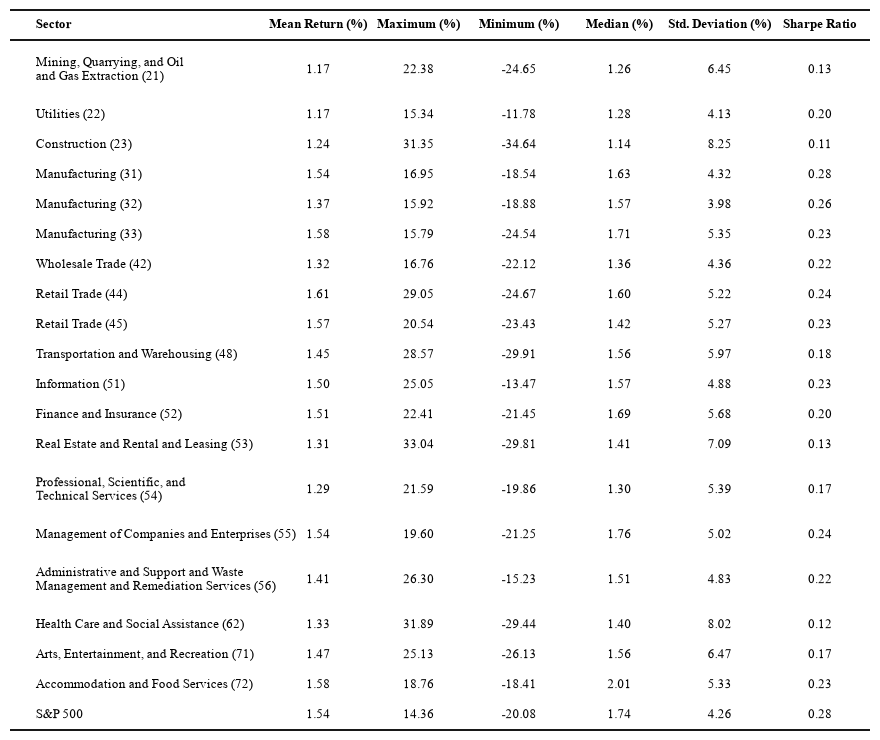

In [14]:
## df_stats als table plot
import re
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

tabelle = df_stats.reset_index()
tabelle = tabelle.rename(columns={
    'index': 'Sector',
    'mittelwert': 'Mean Return',
    'maximum': 'Maximum',
    'minimum': 'Minimum',
    'median': 'Median',
    'std_abweichung': 'Std. Deviation',
    'sharpe_ratio': 'Sharpe Ratio'
})

def sortier_schluessel(name):
    if name == 'S&P 500':
        return float('inf')
    match = re.search(r'\((\d+)\)$', name)
    return int(match.group(1)) if match else float('inf') - 1

tabelle['sortier_key'] = tabelle['Sector'].map(sortier_schluessel)
tabelle = tabelle.sort_values('sortier_key').drop(columns='sortier_key')

umbrueche = {
    'Mining, Quarrying, and Oil and Gas Extraction (21)':
        'Mining, Quarrying, and Oil\nand Gas Extraction (21)',
    'Professional, Scientific, and Technical Services (54)':
        'Professional, Scientific, and\nTechnical Services (54)',
    'Administrative and Support and Waste Management and Remediation Services (56)':
        'Administrative and Support and Waste\nManagement and Remediation Services (56)',
}
for alt, neu in umbrueche.items():
    tabelle['Sector'] = tabelle['Sector'].str.replace(alt, neu, regex=False)

prozent_spalten = ['Mean Return', 'Maximum', 'Minimum', 'Median', 'Std. Deviation']
for spalte in prozent_spalten:
    tabelle[spalte] = (tabelle[spalte] * 100).round(2).map(lambda x: f'{x:,.2f}')

# Sharpe Ratio ebenfalls auf 2 Nachkommastellen (statt vorher 3)
tabelle['Sharpe Ratio'] = tabelle['Sharpe Ratio'].round(2).map(lambda x: f'{x:,.2f}')

col_labels = list(tabelle.columns)
for spalte in prozent_spalten:
    col_labels[col_labels.index(spalte)] = f'{spalte} (%)'

n_rows = len(tabelle)
n_cols = len(col_labels)

fig, ax = plt.subplots(figsize=(1.3 * n_cols + 2, 0.38 * n_rows + 0.8))
ax.axis('off')

tab = ax.table(
    cellText=tabelle.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.30] + [0.7 / (n_cols - 1)] * (n_cols - 1)
)

tab.auto_set_font_size(False)
tab.set_fontsize(9)
tab.scale(1, 1.8)

umbruch_zeilen = [i + 1 for i, name in enumerate(tabelle['Sector']) if '\n' in name]

for (row, col), cell in tab.get_celld().items():
    cell.set_linewidth(0)
    cell.visible_edges = ''
    cell.set_text_props(fontfamily='Times New Roman')
    if col == 0:
        cell.set_text_props(ha='left', fontfamily='Times New Roman')
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='Times New Roman')
        cell.visible_edges = 'B'
        cell.set_linewidth(1.3)
    if row in umbruch_zeilen:
        cell.set_height(cell.get_height() * 2)

fig.canvas.draw()
bbox = tab.get_window_extent(fig.canvas.get_renderer()).transformed(ax.transAxes.inverted())

ax.hlines([bbox.y1, bbox.y0], xmin=bbox.x0, xmax=bbox.x1, transform=ax.transAxes,
          color='black', linewidth=1.3, clip_on=False)

plt.savefig('stats_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [15]:
## drawdowns
# Maximum Drawdown je Sektor und Index in einem neuen DataFrame
max_drawdowns = {}

for spalte in df_returns.columns:
    # kumulierter Vermögensindex (Wachstum von 1 Einheit an, ausgehend vom monatlichen Return)
    kumulierter_wert = (1 + df_returns[spalte]).cumprod()
    
    # bisheriges Allzeithoch zu jedem Zeitpunkt
    laufendes_hoch = kumulierter_wert.cummax()
    
    # Drawdown = prozentualer Abstand vom bisherigen Höchststand
    drawdown = (kumulierter_wert / laufendes_hoch) - 1
    
    # maximaler (=größter) Drawdown über den gesamten Zeitraum
    max_drawdowns[spalte] = drawdown.min()

df_drawdowns = pd.DataFrame({'max_drawdown': pd.Series(max_drawdowns)})

drawdown_listen = []

for spalte in df_returns.columns:
    # kumulierter Vermögensindex und laufendes Allzeithoch
    kumulierter_wert = (1 + df_returns[spalte]).cumprod()
    laufendes_hoch = kumulierter_wert.cummax()
    drawdown = (kumulierter_wert / laufendes_hoch) - 1

    # Monate markieren, in denen wir "unter Wasser" sind (drawdown < 0)
    unter_wasser = drawdown < 0
    
    # jede zusammenhängende unter-Wasser-Periode bekommt eine eigene Gruppen-ID
    gruppe = (unter_wasser != unter_wasser.shift()).cumsum()

    # je Periode: Start, Ende, Länge und tiefster Punkt (=max. Drawdown dieser Periode)
    for gruppen_id, teil in drawdown[unter_wasser].groupby(gruppe[unter_wasser]):
        drawdown_listen.append({
            'sektor': spalte,
            'start': teil.index[0],
            'ende': teil.index[-1],
            'laenge_monate': len(teil),
            'max_drawdown': teil.min()
        })

df_alle_drawdowns = pd.DataFrame(drawdown_listen)
df_alle_drawdowns

## Maximum Drawdown, Länge und Anzahl aller Drawdowns je Sektor und Index

# je Sektor/Index die Zeile mit dem tiefsten Drawdown aus df_alle_drawdowns herausfinden
schlimmste_drawdowns = df_alle_drawdowns.loc[
    df_alle_drawdowns.groupby('sektor')['max_drawdown'].idxmin()
]

# schlimmster Drawdown und dessen Länge, Sektor/Index als Index
df_drawdowns = schlimmste_drawdowns.set_index('sektor')[['max_drawdown', 'laenge_monate']]


# Anzahl aller Drawdown-Episoden je Sektor/Index (unabhängig von deren Tiefe)
anzahl_drawdowns = df_alle_drawdowns.groupby('sektor').size()
df_drawdowns['anzahl_drawdowns'] = anzahl_drawdowns

#df_drawdowns.to_excel("max_drawdowns.xlsx", sheet_name="Max Drawdowns", index=True)
df_drawdowns

## Anzahl der Drawdowns je Sektor/Index nach Tiefe kategorisiert

# absolute Tiefe jedes einzelnen Drawdowns (in %) 
tiefe = df_alle_drawdowns['max_drawdown'].abs()

# Tiefen-Kategorien definieren: <10%, 10-20%, ..., 70-80%, >80%
grenzen = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, np.inf]
labels = ['<10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '>80%']

df_alle_drawdowns['tiefen_kategorie'] = pd.cut(tiefe, bins=grenzen, labels=labels)

# je Sektor/Index zählen, wie viele Drawdowns in welche Kategorie fallen
anzahl_je_kategorie = df_alle_drawdowns.pivot_table(
    index='sektor',
    columns='tiefen_kategorie',
    values='max_drawdown',
    aggfunc='count',
    fill_value=0,
    observed=False
)

# Spaltenreihenfolge festlegen und zu df_drawdowns hinzufügen
anzahl_je_kategorie = anzahl_je_kategorie[labels]
df_drawdowns = df_drawdowns.join(anzahl_je_kategorie)

#Namenszuordnung
df_drawdowns.index = df_drawdowns.index.map(sektor_name)
df_drawdowns = df_drawdowns.rename(index={'ret_index': 'S&P 500'})

#df_drawdowns.to_excel("max_drawdowns.xlsx", sheet_name="Max Drawdowns", index=True)
df_drawdowns

# Maximum Drawdown je Sektor und Index als Excel-Datei ausgeben
df_drawdowns.to_excel("max_drawdowns.xlsx", sheet_name="Max Drawdowns", index=True)

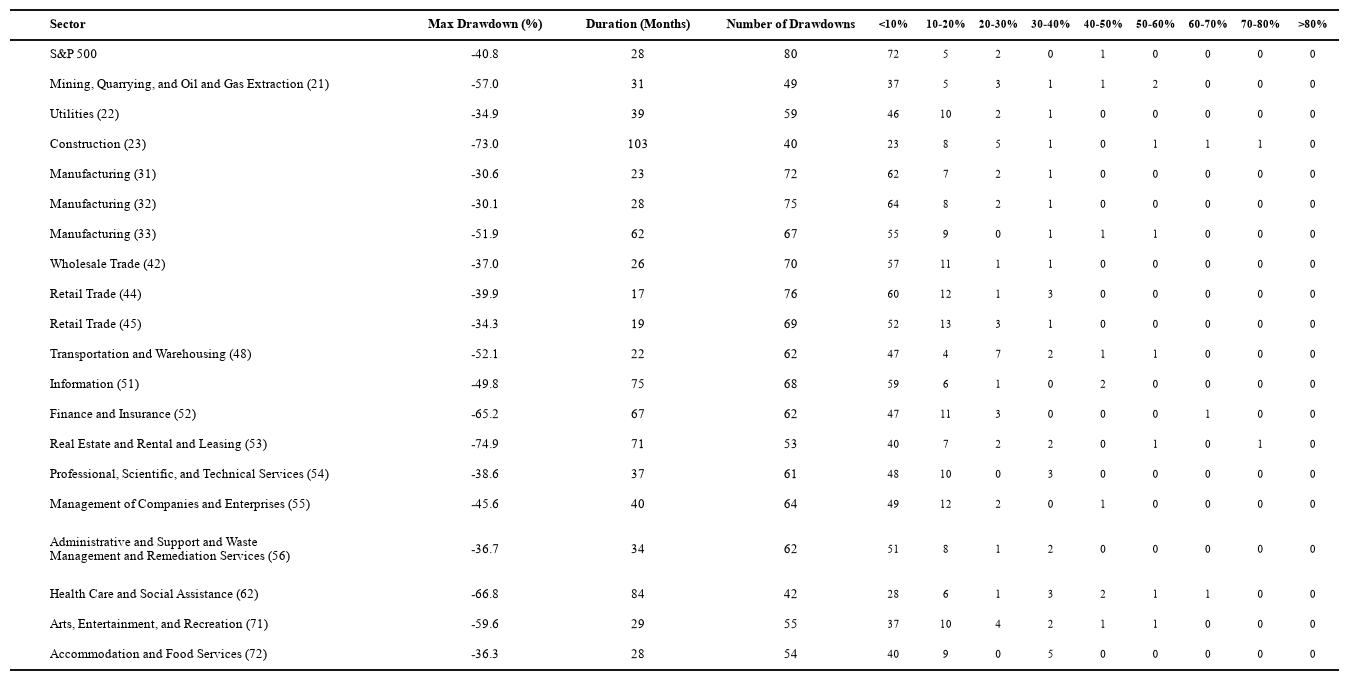

In [16]:
## df_drawdown als table plot
import re
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

tabelle = df_drawdowns.reset_index()
tabelle = tabelle.rename(columns={
    'index': 'Sector',
    'sektor': 'Sector',
    'max_drawdown': 'Max Drawdown',
    'laenge_monate': 'Duration (Months)',
    'anzahl_drawdowns': 'Number of Drawdowns'
})

# Sortierschlüssel: NAICS-Nummer aus dem Namen extrahieren; S&P 500 bekommt -1, damit es oben steht
def sortier_schluessel(name):
    if name == 'S&P 500':
        return -1
    match = re.search(r'\((\d+)\)$', name)
    return int(match.group(1)) if match else float('inf')

tabelle['sortier_key'] = tabelle['Sector'].map(sortier_schluessel)
tabelle = tabelle.sort_values('sortier_key').drop(columns='sortier_key')

# Zeilenumbruch für den langen Sektornamen
tabelle['Sector'] = tabelle['Sector'].str.replace(
    'Administrative and Support and Waste Management and Remediation Services',
    'Administrative and Support and Waste\nManagement and Remediation Services',
    regex=False
)

tabelle['Max Drawdown'] = (tabelle['Max Drawdown'] * 100).round(1).map(lambda x: f'{x:,.1f}')

for spalte in tabelle.columns:
    if spalte not in ['Sector', 'Max Drawdown']:
        tabelle[spalte] = tabelle[spalte].map(lambda x: f'{int(x):,}')

col_labels = list(tabelle.columns)
col_labels[col_labels.index('Max Drawdown')] = 'Max Drawdown (%)'

n_rows = len(tabelle)
n_cols = len(col_labels)

haupt_spalten = ['Sector', 'Max Drawdown (%)', 'Duration (Months)', 'Number of Drawdowns']
n_kategorie_spalten = n_cols - len(haupt_spalten)

sector_breite = 0.30
kern_breite = 0.115
kategorie_breite = (1 - sector_breite - 3 * kern_breite) / n_kategorie_spalten

col_widths = [sector_breite, kern_breite, kern_breite, kern_breite] + [kategorie_breite] * n_kategorie_spalten

fig, ax = plt.subplots(figsize=(1.05 * n_cols + 3.5, 0.38 * n_rows + 0.8))
ax.axis('off')

tab = ax.table(
    cellText=tabelle.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=col_widths
)

tab.auto_set_font_size(False)
tab.set_fontsize(9)
tab.scale(1, 1.8)

umbruch_zeilen = [i + 1 for i, name in enumerate(tabelle['Sector']) if '\n' in name]

for (row, col), cell in tab.get_celld().items():
    cell.set_linewidth(0)
    cell.visible_edges = ''
    cell.set_text_props(fontfamily='Times New Roman')
    if col >= len(haupt_spalten):
        cell.set_fontsize(8)
    if col == 0:
        cell.set_text_props(ha='left', fontfamily='Times New Roman')
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='Times New Roman')
        cell.visible_edges = 'B'
        cell.set_linewidth(1.3)
    if row in umbruch_zeilen:
        cell.set_height(cell.get_height() * 2)

fig.canvas.draw()
bbox = tab.get_window_extent(fig.canvas.get_renderer()).transformed(ax.transAxes.inverted())

# clip_on=False verhindert, dass die Linien abgeschnitten werden, falls die Tabelle
# durch den Zeilenumbruch über die ursprüngliche Achsen-Box hinauswächst
ax.hlines([bbox.y1, bbox.y0], xmin=bbox.x0, xmax=bbox.x1, transform=ax.transAxes,
          color='black', linewidth=1.3, clip_on=False)

plt.savefig('drawdowns_table.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

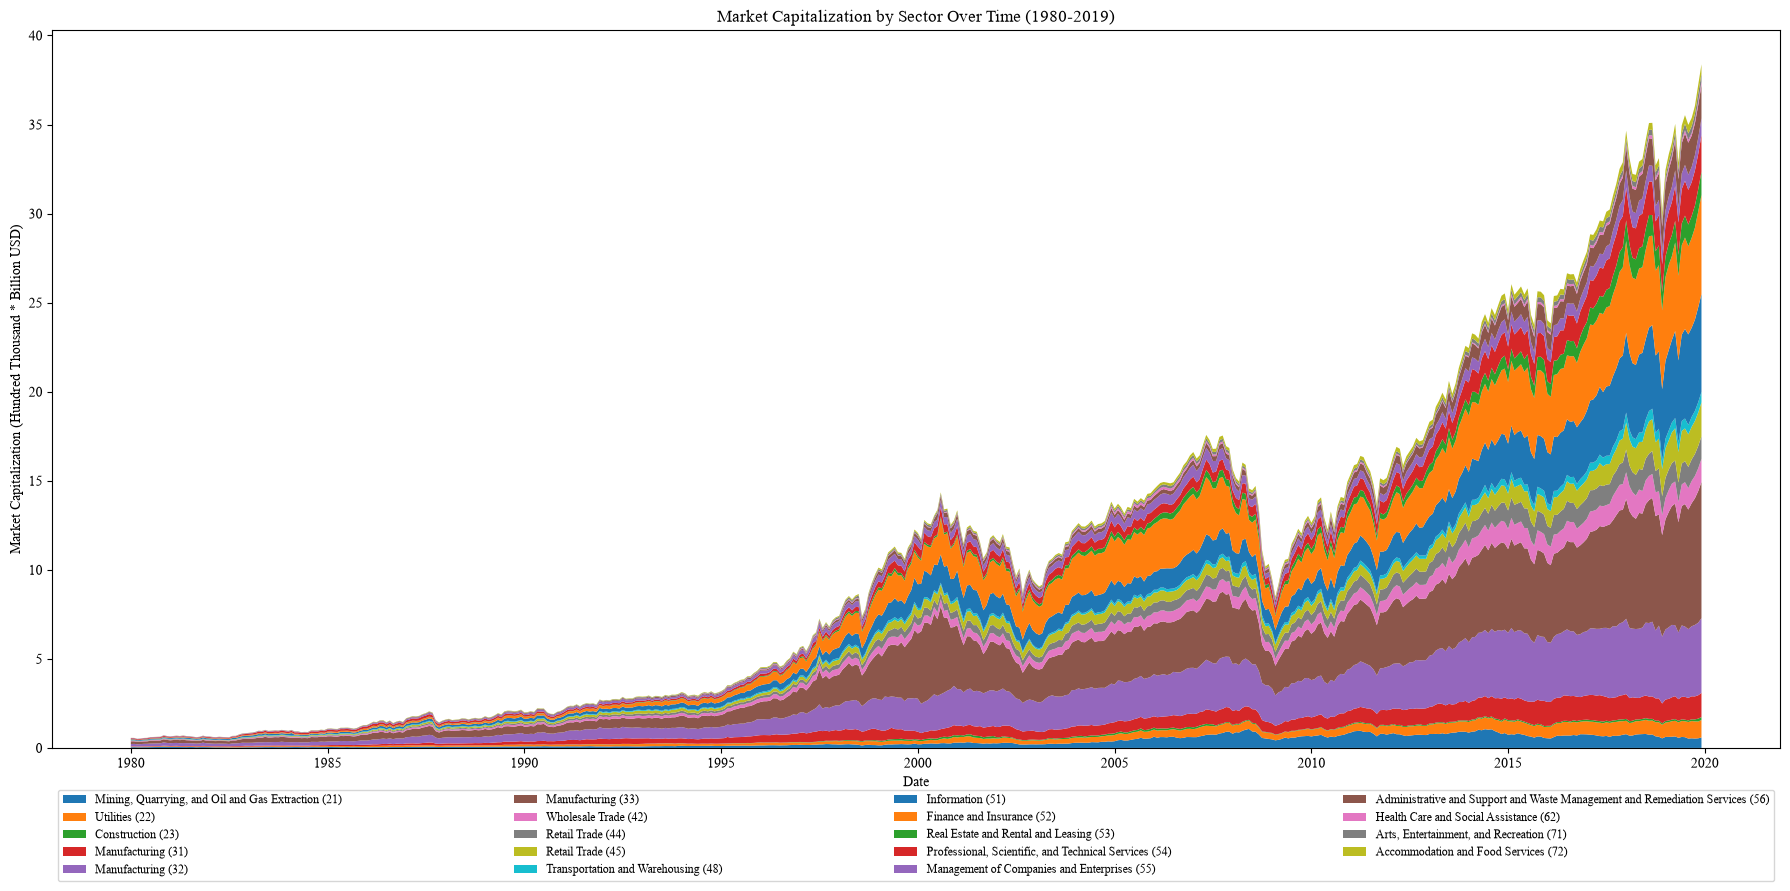

In [17]:
## plotting1

## Area plot of market capitalization by sector over time

import matplotlib.ticker as mticker
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

# convert sector mcap (MultiIndex: date, naics) to wide format (sectors as columns)
sektor_mcap_wide = sektor_mcap_zeitraum.unstack('naics')
sektor_mcap_wide.columns = sektor_mcap_wide.columns.map(sektor_name)

# fill missing values (if a sector has no mcap in a given month) with 0
sektor_mcap_wide = sektor_mcap_wide.fillna(0)
#WIE HÄUFIG KOMMT DAS VOR? FEHLEN HIER DATEN?

# stacked area plot
fig, ax = plt.subplots(figsize=(18, 9))
ax.stackplot(
    sektor_mcap_wide.index,
    sektor_mcap_wide.T.values,
    labels=sektor_mcap_wide.columns
)

ax.set_title('Market Capitalization by Sector Over Time (1980-2019)')
ax.set_xlabel('Date')
ax.set_ylabel('Market Capitalization (Hundred Thousand * Billion USD)')

# format y-axis: divide raw values (in USD) by 1e9 to show them in billions
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x / 1e9:.0f}'))

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0., -0.15, 1., .1),   # (x0, y0, breite, höhe) -> volle Breite = 1.
    mode="expand",                          # streckt die Legende über die gesamte Breite
    ncol=4,
    fontsize='small'
)

plt.tight_layout()
plt.show()

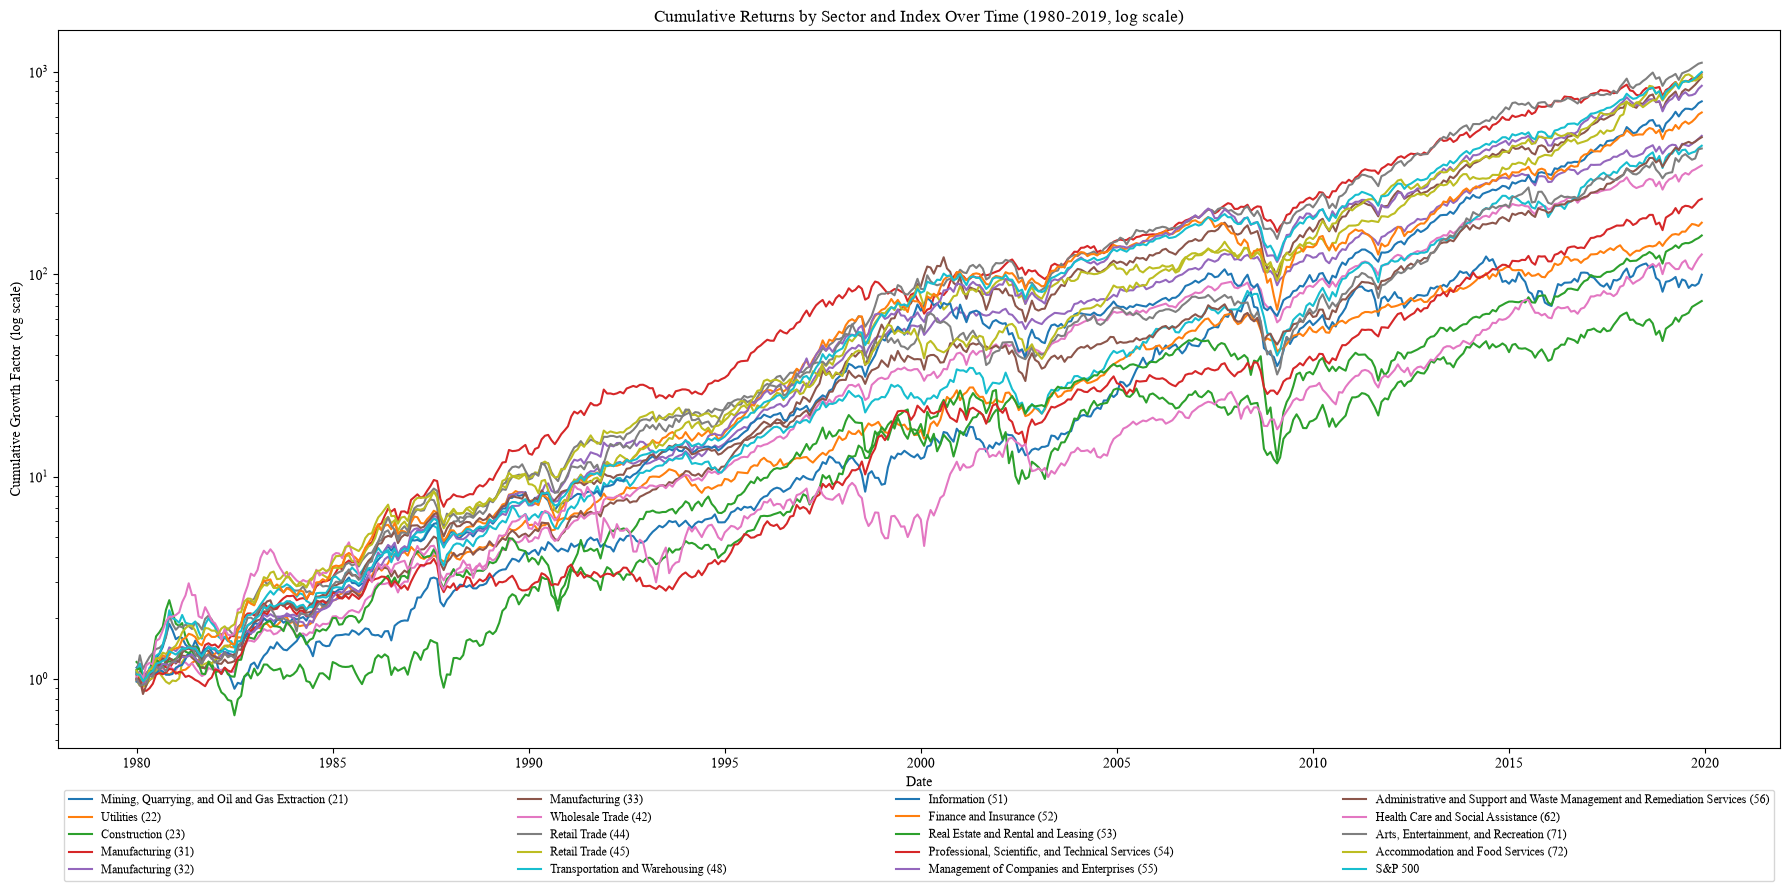

In [18]:
## plotting2

## Line plot of cumulative returns (in %) by sector and index over time

# cumulative growth of 1 unit invested, based on monthly returns
kumulierte_returns = (1 + df_returns).cumprod()
kumulierte_returns.columns = kumulierte_returns.columns.map(sektor_name)
kumulierte_returns = kumulierte_returns.rename(columns={'ret_index': 'S&P 500'})

# convert to cumulative return in percent (e.g. growth factor 2.5 -> +150%)
kumulierte_returns_prozent = (kumulierte_returns - 1) * 100

fig, ax = plt.subplots(figsize=(18, 9))
for spalte in kumulierte_returns.columns:
    ax.plot(kumulierte_returns.index, kumulierte_returns[spalte], label=spalte)

ax.set_yscale('log')  # logarithmische y-Achse

ax.set_title('Cumulative Returns by Sector and Index Over Time (1980-2019, log scale)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Growth Factor (log scale)')

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0., -0.15, 1., .1),   # (x0, y0, breite, höhe) -> volle Breite = 1.
    mode="expand",                          # streckt die Legende über die gesamte Breite
    ncol=4,
    fontsize='small'
)

plt.tight_layout()
plt.show()

Stichtag: 2019-12-01 00:00:00


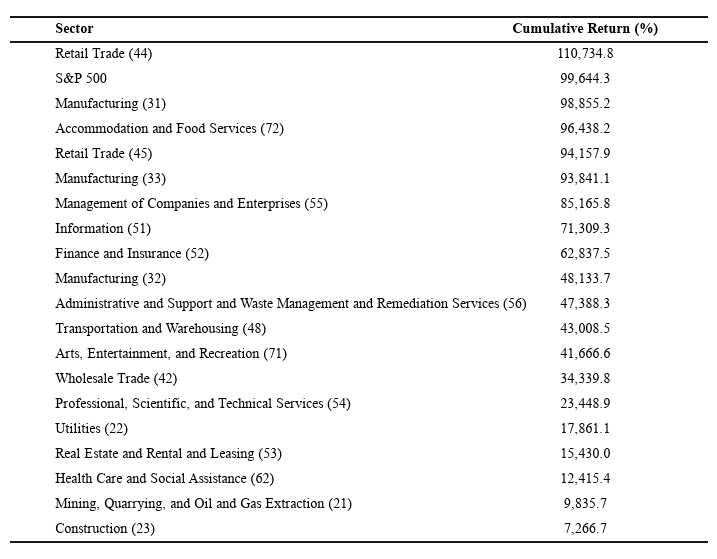

In [19]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'

# Letzte verfügbare Zeile (Ende des Betrachtungszeitraums)
stichtag = kumulierte_returns_prozent.iloc[-1].sort_values(ascending=False)
print("Stichtag:", kumulierte_returns_prozent.index[-1])  # zur Kontrolle

tabelle = stichtag.round(1).reset_index()
tabelle.columns = ['Sector', 'Cumulative Return']
tabelle['Cumulative Return'] = tabelle['Cumulative Return'].map(lambda x: f'{x:,.1f}')

col_labels = ['Sector', 'Cumulative Return (%)']
n_rows = len(tabelle)

fig, ax = plt.subplots(figsize=(9, 0.32 * n_rows + 0.6))
ax.axis('off')

tab = ax.table(
    cellText=tabelle.values,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    colWidths=[0.65, 0.35]
)

tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1, 1.5)

for (row, col), cell in tab.get_celld().items():
    cell.set_linewidth(0)
    cell.visible_edges = ''
    cell.set_text_props(fontfamily='Times New Roman')
    if col == 0:
        cell.set_text_props(ha='left', fontfamily='Times New Roman')
    if row == 0:
        cell.set_text_props(weight='bold', fontfamily='Times New Roman')
        cell.visible_edges = 'B'
        cell.set_linewidth(1.3)

fig.canvas.draw()
bbox = tab.get_window_extent(fig.canvas.get_renderer()).transformed(ax.transAxes.inverted())
ax.hlines([bbox.y1, bbox.y0], xmin=bbox.x0, xmax=bbox.x1, transform=ax.transAxes,
          color='black', linewidth=1.3)

plt.savefig('cumulative_returns_2019.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()